🌟 **Daily Challenge: NumPy, Pandas, and Matplotlib Integration**

Use NumPy to generate monthly temperatures, Pandas to compare annual averages, and Matplotlib to visualize the results for 10 cities.

Run the cells from top to bottom. Required packages: numpy, pandas and matplotlib. No external data file is needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

**🌟 Task 1: Data Preparation**

I generate 12 monthly temperatures for each of 10 cities, using values between −5°C and 35°C. A fixed random seed keeps the results reproducible. The city names are labels for synthetic data, not actual weather records.

In [2]:
# Generate a 10-by-12 array of monthly temperatures.
np.random.seed(42)

cities = ["London", "Paris", "New York", "Tokyo", "Sydney",
          "Cape Town", "Cairo", "Mumbai", "Toronto", "Tel Aviv"]
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

temperatures = np.random.uniform(low=-5, high=35, size=(10, 12))

# Use cities as rows and months as columns.
temperature_df = pd.DataFrame(temperatures, index=cities, columns=months)
temperature_df.index.name = "City"

print("Dataset shape:", temperature_df.shape)
display(temperature_df.round(2))

Dataset shape: (10, 12)


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
City,,,,,,,,,,,,
London,9.98,33.03,24.28,18.95,1.24,1.24,-2.68,29.65,19.04,23.32,-4.18,33.80
Paris,28.30,3.49,2.27,2.34,7.17,15.99,12.28,6.65,19.47,0.58,6.69,9.65
New York,13.24,26.41,2.99,15.57,18.70,-3.14,19.30,1.82,-2.40,32.96,33.63,27.34
Tokyo,7.18,-1.09,22.37,12.61,-0.12,14.81,-3.62,31.37,5.35,21.50,7.47,15.80
Sydney,16.87,2.39,33.78,26.01,32.58,30.79,18.92,31.87,-1.46,2.84,-3.19,8.01
Cape Town,10.55,5.85,28.15,9.27,6.24,16.71,0.64,27.09,-2.02,34.48,25.89,2.95
Cairo,-4.78,27.62,23.27,24.16,25.85,-2.04,9.34,-0.37,29.52,19.93,8.24,-2.46
Mumbai,7.44,8.01,24.18,20.50,30.49,13.89,-0.22,23.53,25.43,17.45,25.84,14.75
Toronto,15.91,12.10,-3.98,-0.68,-3.74,20.46,7.57,15.34,31.30,4.97,11.42,25.22


None

**🌟 Task 2: Data Analysis**

I use `mean(axis=1)` to average the 12 months in each city row. Each month receives equal weight. I keep the original values for calculations and round only the displayed results.

In [3]:
# Calculate the annual average temperature for each city.
annual_average = temperature_df.mean(axis=1)
annual_average.name = "Annual average (°C)"

display(annual_average.to_frame().round(2))

,Annual average (°C)
City,
London,15.64
Paris,9.57
New York,15.53
Tokyo,11.14
Sydney,16.62
Cape Town,13.82
Cairo,13.19
Mumbai,17.61
Toronto,11.32


None

In [4]:
# Find the cities with the highest and lowest annual averages.
warmest_city = annual_average.idxmax()
coldest_city = annual_average.idxmin()

print(f"Highest annual average: {warmest_city}, {annual_average[warmest_city]:.2f}°C")
print(f"Lowest annual average: {coldest_city}, {annual_average[coldest_city]:.2f}°C")

Highest annual average: Mumbai, 17.61°C
Lowest annual average: Paris, 9.57°C


None

**🌟 Task 3: Data Visualization**

I show each city's monthly temperatures in a separate line plot to keep the lines easy to follow. All plots use the same temperature scale, so the cities can be compared directly.

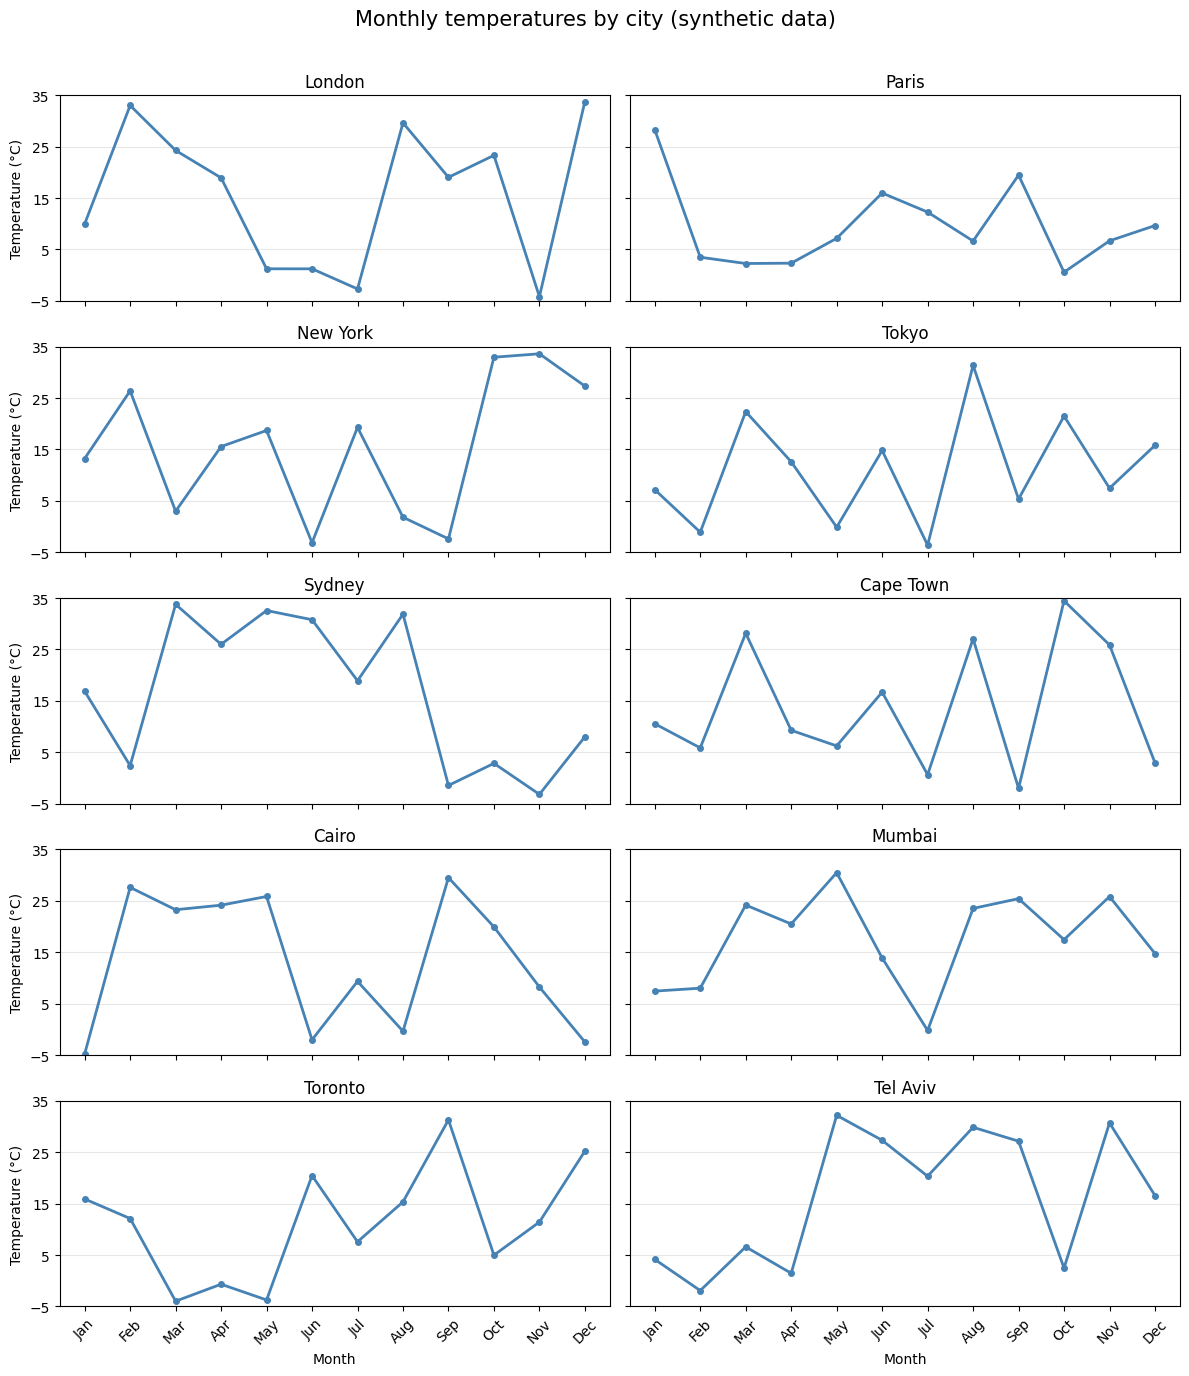

None

In [5]:
# Plot monthly temperatures with a shared scale for all cities.
fig, axes = plt.subplots(5, 2, figsize=(12, 14), sharex=True, sharey=True)

for ax, city in zip(axes.flat, cities):
    ax.plot(months, temperature_df.loc[city], marker="o",
            color="steelblue", linewidth=2, markersize=4)
    ax.set_title(city)
    ax.set_ylim(-5, 35)
    ax.set_yticks([-5, 5, 15, 25, 35])
    ax.grid(axis="y", alpha=0.3)

for ax in axes[:, 0]:
    ax.set_ylabel("Temperature (°C)")
for ax in axes[-1, :]:
    ax.set_xlabel("Month")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Monthly temperatures by city (synthetic data)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

The monthly values rise and fall irregularly. The data generation does not include seasons or local climate, so these changes should not be interpreted as real seasonal patterns.

I sort the annual averages in a horizontal bar chart to make the warmest and coldest cities easier to identify.

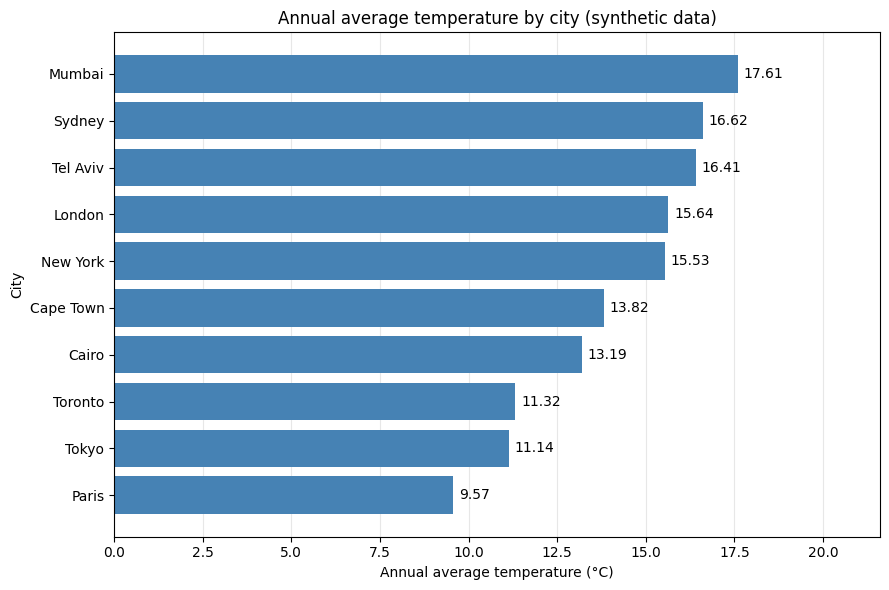

None

In [6]:
# Compare annual average temperatures from lowest to highest.
sorted_average = annual_average.sort_values()
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(sorted_average.index, sorted_average.values, color="steelblue")
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.set_title("Annual average temperature by city (synthetic data)")
ax.set_xlabel("Annual average temperature (°C)")
ax.set_ylabel("City")
ax.set_xlim(0, sorted_average.max() + 4)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**🌟 Summary of Findings**

I summarize the annual averages and compare the monthly averages across all 10 cities. The results below are calculated from the data, so they update if the generated values change.

In [7]:
# Summarize the main findings from the generated dataset.
monthly_average = temperature_df.mean(axis=0)
warmest_month = monthly_average.idxmax()
coldest_month = monthly_average.idxmin()
average_difference = annual_average[warmest_city] - annual_average[coldest_city]

print(f"The dataset contains {temperature_df.size} monthly temperatures for 10 cities.")
print(f"{warmest_city} has the highest annual average: {annual_average[warmest_city]:.2f}°C.")
print(f"{coldest_city} has the lowest annual average: {annual_average[coldest_city]:.2f}°C.")
print(f"The difference between these annual averages is {average_difference:.2f}°C.")
print(f"Across the 10 cities, {warmest_month} has the highest monthly average: {monthly_average[warmest_month]:.2f}°C.")
print(f"Across the 10 cities, {coldest_month} has the lowest monthly average: {monthly_average[coldest_month]:.2f}°C.")

The dataset contains 120 monthly temperatures for 10 cities.
Mumbai has the highest annual average: 17.61°C.
Paris has the lowest annual average: 9.57°C.
The difference between these annual averages is 8.03°C.
Across the 10 cities, Aug has the highest monthly average: 19.68°C.
Across the 10 cities, Jul has the lowest monthly average: 8.19°C.


None

The line plots show month-to-month variation, while the bar chart summarizes the overall temperature level for each city. An annual average can hide large differences between individual months.

These findings describe this synthetic sample only. All cities and months use the same uniform distribution, so the differences arise from random sampling. They do not establish real climate differences, seasonal trends, or global warming.